In [2]:
import os
from pathlib import Path

# Always run from the project root regardless of where the notebook lives.
# This makes all relative paths (data/mvtec, results/, etc.) consistent
# with how the scripts and src/ package use them.
repo_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(repo_root)
print(f"Working directory: {Path.cwd()}")

Working directory: c:\GitHub\anomaly-detection-mvtec


In [3]:
import matplotlib.pyplot as plt
import torch
from IPython.display import Image as IPImage
from torch.utils.data import DataLoader

from anomaly_det.data import (
    MVTecDataset,
    get_mask_transform,
    get_test_transform,
    get_train_transform,
)
from anomaly_det.evaluation import (
    evaluate_category,
    plot_score_distribution,
    save_category_figure,
)
from anomaly_det.models import PatchCore

In [4]:
CATEGORY = "bottle"
IMAGE_SIZE = 224

model = PatchCore(coreset_ratio=0.01)

train_dl = DataLoader(
    MVTecDataset("data/mvtec", CATEGORY, "train",
                 transform=get_train_transform(IMAGE_SIZE)),
    batch_size=32, num_workers=0, pin_memory=True,
)
model.fit(train_dl)

[PatchCore] Building memory bank  (wide_resnet50_2 · layers=['layer2', 'layer3'] · device=cuda)


  Extracting patch features: 100%|██████████| 7/7 [00:05<00:00,  1.30it/s]


  Total patches :    163,856
  Feature dim   :      1,536


  Coreset size  :      1,638  (1.00% of patches)
[PatchCore] Memory bank ready — 1,638 vectors indexed.



PatchCore(backbone='wide_resnet50_2', layers=['layer2', 'layer3'], coreset_ratio=0.01, k=1, device=cuda, status='fitted, 1,638 vectors')

In [5]:
test_ds = MVTecDataset(
    "data/mvtec", CATEGORY, "test",
    transform=get_test_transform(IMAGE_SIZE),
    mask_transform=get_mask_transform(IMAGE_SIZE),
)
test_dl = DataLoader(test_ds, batch_size=32, num_workers=0)

result = evaluate_category(model, test_dl, CATEGORY)
print(result.summary())

  Evaluating bottle: 100%|██████████| 3/3 [00:03<00:00,  1.17s/it]


────────────────────────────────────────
  Category    : bottle
  Image AUROC : 1.0000
  Pixel AUROC : 0.9842
  Test images : 83 (20 normal, 63 anomalous)
────────────────────────────────────────


  Saved figure → results\figures\bottle_comparison.png


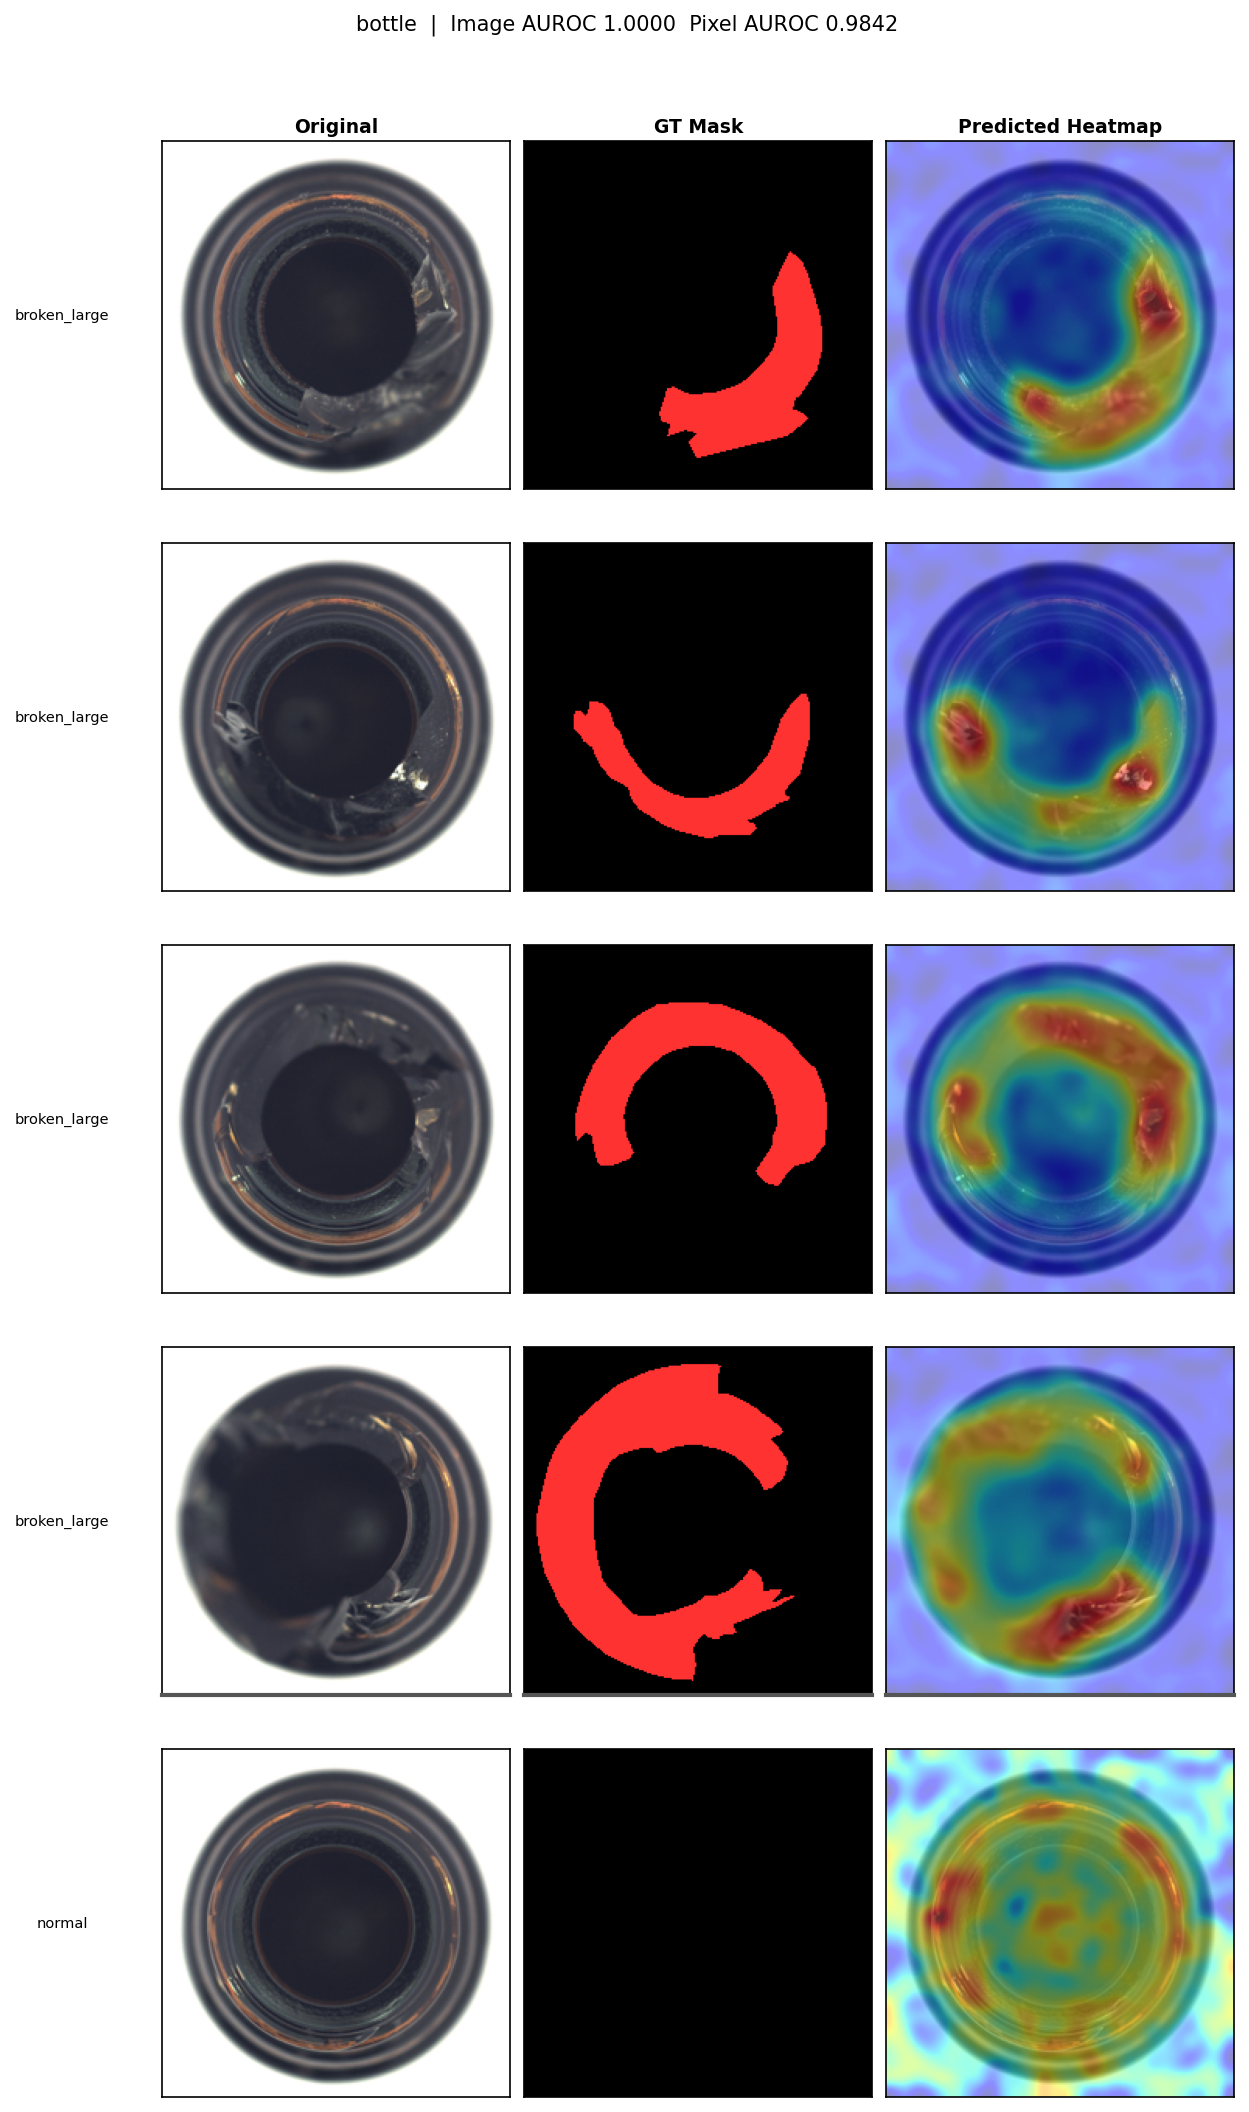

In [6]:
fig_path = Path("results/figures") / f"{CATEGORY}_comparison.png"
save_category_figure(
    result, test_ds, fig_path,
    n_anomalous=4, n_normal=1,
)
IPImage(str(fig_path))

  Saved histogram → results\figures\bottle_scores.png


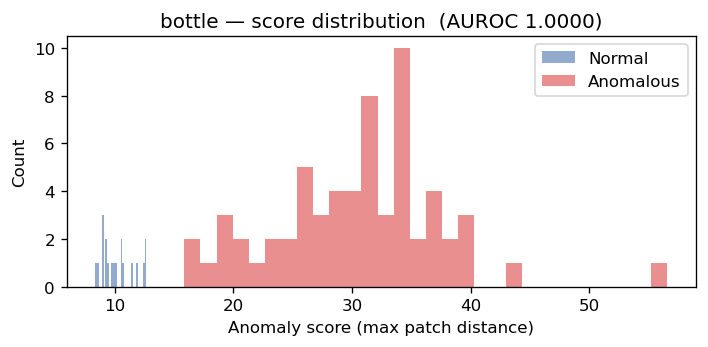

In [7]:
plot_score_distribution(result, output_path=Path("results/figures") / f"{CATEGORY}_scores.png")
plt.show()

In [8]:
model.save(f"results/checkpoints/{CATEGORY}")

[PatchCore] Saved to results\checkpoints\bottle
